In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Section 1 — Supervised Learning: Regression

Part 1.1 — Load and explore the taxi data

Shape:
(41202, 13)

First five rows:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Summary statistics:


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


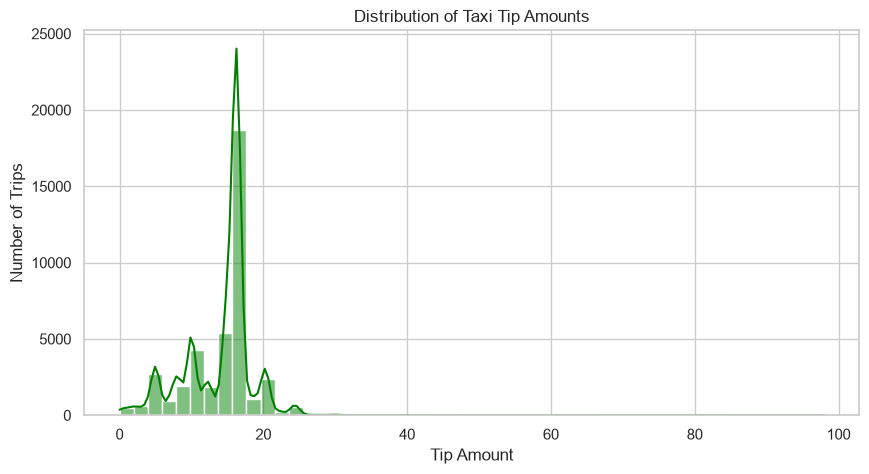

In [2]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
# - taxi.describe()
# - count missing values per column: taxi.isna().sum()
print("Shape:")
print(taxi.shape)

print("\nFirst five rows:")
display(taxi.head())

print("\nDataset information:")
taxi.info()

print("\nSummary statistics:")
display(taxi.describe())

print("\nMissing values per column:")
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
plt.figure(figsize=(10, 5))
sns.histplot(data=taxi, x="tip_amount", bins=50, kde=True, color="green")
plt.title("Distribution of Taxi Tip Amounts")
plt.xlabel("Tip Amount")
plt.ylabel("Number of Trips")
plt.show()

Student Reasoning — Taxi data exploration

The dataset has 41,202 rows and 13 columns. There are no missing values because all columns have 41,202 non-null values.

There are no negative tips because the minimum tip_amount is 0.01. There are also no zero tips. However, trip_distance has a minimum value of 0, so there are zero-distance trips. These trips may be unusual or incorrect.

The tip_amount values range from 0.01 to 98.00. Most tips are between about 10 and 20, and the highest number of trips is around 16.19. The distribution has a right tail because a few trips have much higher tips, up to 98. These values may be outliers.

For preprocessing, I will not need to fill missing values. I will check the zero-distance trips and examine very high tip amounts before training the model.


Part 1.2 — Preprocessing & feature engineering

In [3]:
#TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
taxi_clean = taxi.copy()

# Remove rows with missing values
taxi_clean = taxi_clean.dropna()

# Keep only valid trips:
# - trip distance must be greater than 0
# - fare amount must be greater than 0
# - tip amount cannot be negative
taxi_clean = taxi_clean[
    (taxi_clean["trip_distance"] > 0) &
    (taxi_clean["fare_amount"] > 0) &
    (taxi_clean["tip_amount"] >= 0)
].copy()

print("Rows before cleaning:", taxi.shape[0])
print("Rows after cleaning:", taxi_clean.shape[0])

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

taxi_clean["fare_per_mile"] = (
    taxi_clean["fare_amount"] / taxi_clean["trip_distance"]
)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
y = taxi_clean["tip_amount"]
X = taxi_clean.drop(columns="tip_amount")

# These are category labels, even though most are written as numbers
categorical_columns = [
    "VendorID",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type"
]

# Convert each category into 0/1 columns
X = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

# Numeric columns remain as numeric values
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile"
]

print("\nFeature matrix shape after encoding:", X.shape)
print("Target shape:", y.shape)
display(X.head())

# TODO: Scale the numeric features.
#   from sklearn.preprocessing import StandardScaler   (fit on TRAIN only — see Part 1.3)

Rows before cleaning: 41202
Rows after cleaning: 41126

Feature matrix shape after encoding: (41126, 269)
Target shape: (41126,)


,passenger_count,trip_distance,fare_amount,mta_tax,tolls_amount,improvement_surcharge,fare_per_mile,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1,PULocationID_43,PULocationID_48,PULocationID_50,PULocationID_56,PULocationID_62,PULocationID_68,PULocationID_70,PULocationID_75,PULocationID_76,PULocationID_79,PULocationID_82,PULocationID_83,PULocationID_87,PULocationID_90,PULocationID_113,PULocationID_129,PULocationID_130,PULocationID_132,PULocationID_134,PULocationID_138,PULocationID_141,PULocationID_142,PULocationID_145,PULocationID_148,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_166,PULocationID_170,PULocationID_181,PULocationID_186,PULocationID_194,PULocationID_198,PULocationID_209,PULocationID_213,PULocationID_215,PULocationID_216,PULocationID_219,PULocationID_223,PULocationID_230,PULocationID_231,PULocationID_236,PULocationID_243,PULocationID_255,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_264,DOLocationID_4,DOLocationID_7,DOLocationID_9,DOLocationID_10,DOLocationID_11,DOLocationID_12,DOLocationID_13,DOLocationID_14,DOLocationID_15,DOLocationID_16,DOLocationID_17,DOLocationID_19,DOLocationID_20,DOLocationID_21,DOLocationID_22,DOLocationID_24,DOLocationID_25,DOLocationID_26,DOLocationID_28,DOLocationID_29,DOLocationID_33,DOLocationID_35,DOLocationID_36,DOLocationID_37,DOLocationID_38,DOLocationID_39,DOLocationID_40,DOLocationID_41,DOLocationID_42,DOLocationID_43,DOLocationID_44,DOLocationID_45,DOLocationID_48,DOLocationID_49,DOLocationID_50,DOLocationID_51,DOLocationID_52,DOLocationID_53,DOLocationID_54,DOLocationID_55,DOLocationID_56,DOLocationID_57,DOLocationID_58,DOLocationID_60,DOLocationID_61,DOLocationID_62,DOLocationID_63,DOLocationID_64,DOLocationID_65,DOLocationID_66,DOLocationID_67,DOLocationID_68,DOLocationID_70,DOLocationID_71,DOLocationID_72,DOLocationID_74,DOLocationID_75,DOLocationID_76,DOLocationID_77,DOLocationID_79,DOLocationID_80,DOLocationID_81,DOLocationID_82,DOLocationID_83,DOLocationID_85,DOLocationID_86,DOLocationID_87,DOLocationID_88,DOLocationID_89,DOLocationID_90,DOLocationID_91,DOLocationID_92,DOLocationID_93,DOLocationID_95,DOLocationID_97,DOLocationID_98,DOLocationID_100,DOLocationID_101,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_108,DOLocationID_111,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_121,DOLocationID_122,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_127,DOLocationID_128,DOLocationID_129,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_137,DOLocationID_138,DOLocationID_139,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_148,DOLocationID_149,DOLocationID_150,DOLocationID_151,DOLocationID_152,DOLocationID_154,DOLocationID_155,DOLocationID_157,DOLocationID_158,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_165,DOLocationID_166,DOLocationID_167,DOLocationID_168,DOLocationID_169,DOLocationID_170,DOLocationID_171,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_185,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_190,DOLocationID_191,DOLocationID_192,DOLocationID_193,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_201,DOLocationID_202,DOLocationID_203,DOLocationID_205,DOLocationID_206,DOLocationID_208,DOLocationID_209,DOLocationID_210,DOLocationID_211,DOLocationID_213,DOLocationID_215,DOLocationID_216,DOLocationID_218,DOLocationID_219,DOLocationID_220,DOLocationID_222,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_227,DOLocationID_228,DOLocationID_229,DOLocationID_230,DOLocationID_231,DOLocationID_232,DOLocationID_233,DOLocationID_234,DOLoca


Student Reasoning — Taxi preprocessing

1. I first removed missing values, although the dataset did not contain any. I then removed rows where trip_distance was less than or equal to zero, fare_amount was less than or equal to zero, or tip_amount was negative. These values are not appropriate for completed taxi trips and could reduce the quality of the model. This reduced the dataset from 41,202 rows to 41,126 rows.

2. I created a new feature called fare_per_mile, calculated by dividing fare_amount by trip_distance. This feature shows the cost of the trip for each mile travelled. It may help the model because trips with similar distances can have different fares due to traffic, rate codes, tolls, or location-related pricing.

3. I will use StandardScaler to scale the numeric features. It changes numeric columns so they are on a similar scale, which prevents features with larger values, such as fare_amount, from having more influence than smaller-value features, such as mta_tax. I will fit the scaler only on the training data and then use it to transform the validation and test data, to avoid data leakage.

Part 1.3 — Train / Validation / Test split

In [4]:
%pip install --no-cache-dir scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.
# First: keep 20% of the data for final testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Second: split the remaining 80% into 60% training and 20% validation
# 0.25 of 80% = 20% of the full dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)
scaler = StandardScaler()

# Learn the mean and standard deviation from training data only
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

# Apply the same training-based scaling to validation and test data
X_val_scaled[numeric_columns] = scaler.transform(
    X_val[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("\nScaling completed.")

Training set: (24675, 269) (24675,)
Validation set: (8225, 269) (8225,)
Test set: (8226, 269) (8226,)

Scaling completed.


Student Reasoning — Splitting

I used 60% of the data for training, 20% for validation, and 20% for testing.

The validation set is useful because I can use it to check the model while I am choosing or improving it. For example, I can compare models or change model settings using the validation results. The test set should only be used at the end to give a final and fair evaluation of the model.

The scaler and any imputation values must be fitted only on the training data because the validation and test data should be treated as new data. If I use information from them during scaling , the model can indirectly learn from them before evaluation. 

Part 1.4 — Train a regressor and check for overfitting

LINEAR REGRESSION
Training: RMSE = 4.776, R² = 0.062
Validation: RMSE = 5.047, R² = 0.045
Test: RMSE = 5.017, R² = 0.050

RANDOM FOREST REGRESSION
Training: RMSE = 2.841, R² = 0.668
Validation: RMSE = 5.651, R² = -0.197
Test: RMSE = 5.624, R² = -0.194


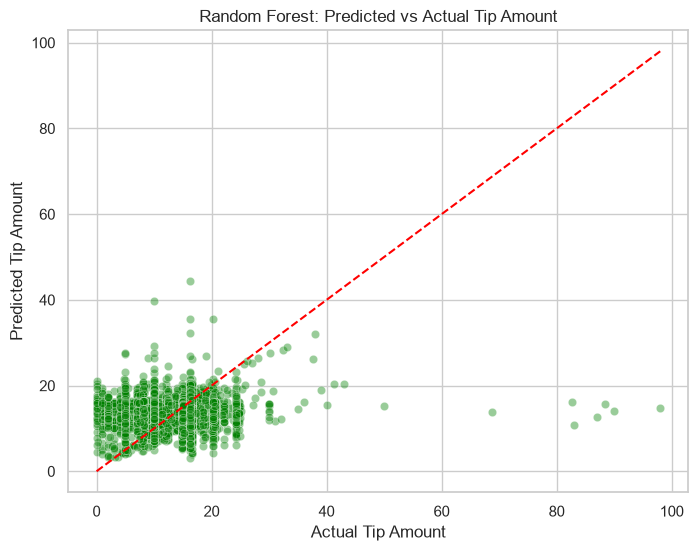

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
forest_model.fit(X_train_scaled, y_train)

# TODO: Predict on train, validation, and test sets.
linear_train_pred = linear_model.predict(X_train_scaled)
linear_val_pred = linear_model.predict(X_val_scaled)
linear_test_pred = linear_model.predict(X_test_scaled)

forest_train_pred = forest_model.predict(X_train_scaled)
forest_val_pred = forest_model.predict(X_val_scaled)
forest_test_pred = forest_model.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
def evaluate_regression(y_true, y_pred, set_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{set_name}: RMSE = {rmse:.3f}, R² = {r2:.3f}")

print("LINEAR REGRESSION")
evaluate_regression(y_train, linear_train_pred, "Training")
evaluate_regression(y_val, linear_val_pred, "Validation")
evaluate_regression(y_test, linear_test_pred, "Test")

print("\nRANDOM FOREST REGRESSION")
evaluate_regression(y_train, forest_train_pred, "Training")
evaluate_regression(y_val, forest_val_pred, "Validation")
evaluate_regression(y_test, forest_test_pred, "Test")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=forest_test_pred, alpha=0.4, color="green")

minimum = min(y_test.min(), forest_test_pred.min())
maximum = max(y_test.max(), forest_test_pred.max())

plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", color="red")
plt.title("Random Forest: Predicted vs Actual Tip Amount")
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.show()

Student Reasoning — Regression evaluation & overfitting 

1. The Linear Regression model performed better on the validation set. Its validation RMSE was 5.047 and its R² was 0.045. The Random Forest had a validation RMSE of 5.651 and R² of -0.197. I used Linear Regression and Random Forest with 100 trees.

2. Linear Regression did not overfit because its results were similar: training RMSE was 4.776, validation RMSE was 5.047, and test RMSE was 5.017. However, its R² values were low, so it did not predict tip amounts very well.
The Random Forest model overfitted. Its training RMSE was 2.841, but its validation RMSE increased to 5.651 and test RMSE was 5.624. Its training R² was 0.668, while validation and test R² were negative. This means it worked well on training data but poorly on new data.

3. To reduce overfitting, I would make the Random Forest less complex. For example, I could limit the depth of the trees or increase the minimum number of samples in each leaf.

# Section 2 — Supervised Learning: Multi-class Classification

Part 2.1 — Load and explore the obesity data

Shape:
(2111, 17)

First five rows:


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                    

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


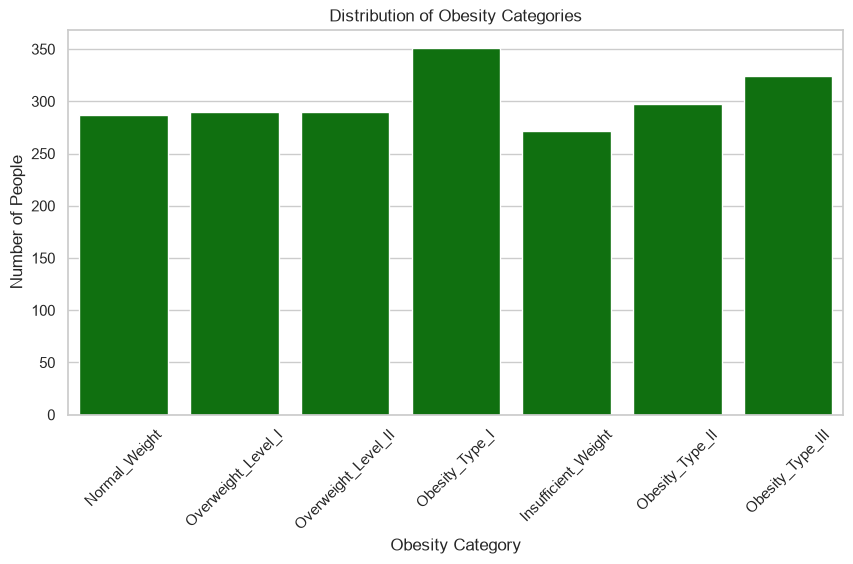

In [7]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)
# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:")
print(obesity.shape)

print("\nFirst five rows:")
display(obesity.head())

print("\nDataset information:")
obesity.info()

print("\nSummary statistics:")
display(obesity.describe())

print("\nMissing values per column:")
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
print("\nClass distribution:")
print(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, x="NObeyesdad", color= "green")
plt.title("Distribution of Obesity Categories")
plt.xlabel("Obesity Category")
plt.ylabel("Number of People")
plt.xticks(rotation=45)
plt.show()

Student Reasoning — Obesity data exploration 

The dataset has 2,111 rows and 17 columns. There are 16 feature columns and one target column called NObeyesdad.

The numeric columns are Age, Height, Weight, FCVC, NCP, CH2O, FAF, and TUE. The other columns, such as Gender, FAVC, CAEC, SMOKE, CALC, and MTRANS, are categorical.

The target has 7 classes and it is fairly balanced. The largest class has 351 people and the smallest class has 272 people. Class balance matters because if one class has very few examples, the model may not learn how to predict it well.

Part 2.2 — Preprocessing & feature engineering

In [8]:
obesity = pd.read_csv(OBESITY_URL)
print(obesity.shape)
display(obesity.head())

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [9]:
from sklearn.preprocessing import LabelEncoder

# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).
obesity_clean = obesity.copy()

# Convert binary yes/no columns into 0/1
binary_columns = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for column in binary_columns:
    obesity_clean[column] = obesity_clean[column].map({
        "no": 0,
        "yes": 1
    })

# CAEC and CALC 
frequency_order = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

obesity_clean["CAEC"] = obesity_clean["CAEC"].map(frequency_order)
obesity_clean["CALC"] = obesity_clean["CALC"].map(frequency_order)

# Gender and MTRANS 
obesity_clean = pd.get_dummies(
    obesity_clean,
    columns=["Gender", "MTRANS"],
    drop_first=True
)


# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity_clean["BMI"] = (
    obesity_clean["Weight"] / (obesity_clean["Height"] ** 2)
)

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder
target_encoder = LabelEncoder()

obesity_clean["NObeyesdad_encoded"] = target_encoder.fit_transform(
    obesity_clean["NObeyesdad"]
)

print("Target classes and their encoded labels:")
for number, category in enumerate(target_encoder.classes_):
    print(f"{number}: {category}")


# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
print("\nProcessed dataset shape:", obesity_clean.shape)
display(obesity_clean.head())

Target classes and their encoded labels:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II

Processed dataset shape: (2111, 22)


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI,NObeyesdad_encoded
0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Normal_Weight,False,False,False,True,False,24.386526,1
1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Normal_Weight,False,False,False,True,False,24.238227,1
2,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Normal_Weight,True,False,False,True,False,23.765432,1
3,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Overweight_Level_I,True,False,False,False,True,26.851852,5
4,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Overweight_Level_II,True,False,False,True,False,28.342381,6


Student Reasoning — Obesity preprocessing 
1. I changed the yes/no columns into 0 and 1 because they only have two possible values. I used ordered numbers for CAEC and CALC because their values show frequency, from no to Always. I used one-hot encoding for Gender and MTRANS because these categories do not have a meaningful order.

2. I created BMI using weight and height. BMI is useful because it gives one measure that combines height and weight. However, obesity levels are strongly related to BMI, so it can make the task easier. It is still fair to include because BMI was calculated from input features only, not from the target column NObeyesdad.

3. I will use StandardScaler for the numeric features. I chose it because the numeric columns have different ranges, such as weight, height, and age. It will put them on a similar scale. I will fit it only on the training data in the next part.

Part 2.3 — Stratified Train / Validation / Test split

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Separate X (features) and y (encoded NObeyesdad).
y_obesity = obesity_clean["NObeyesdad_encoded"]


X_obesity = obesity_clean.drop(
    columns=["NObeyesdad", "NObeyesdad_encoded"]
)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
# First split: 80% train+validation and 20% test
X_ob_train_val, X_ob_test, y_ob_train_val, y_ob_test = train_test_split(
    X_obesity,
    y_obesity,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_obesity
)

# Second split: 75% of the remaining 80% = 60% training,
# and 25% of the remaining 80% = 20% validation
X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_train_val,
    y_ob_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_ob_train_val
)

print("Training set:", X_ob_train.shape, y_ob_train.shape)
print("Validation set:", X_ob_val.shape, y_ob_val.shape)
print("Test set:", X_ob_test.shape, y_ob_test.shape)
# TODO: Fit the scaler on the training set only, then transform train / val / test.
numeric_obesity_columns = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "BMI"
]

scaler_obesity = StandardScaler()

X_ob_train_scaled = X_ob_train.copy()
X_ob_val_scaled = X_ob_val.copy()
X_ob_test_scaled = X_ob_test.copy()

# Fit the scaler only on training data
X_ob_train_scaled[numeric_obesity_columns] = scaler_obesity.fit_transform(
    X_ob_train[numeric_obesity_columns]
)


X_ob_val_scaled[numeric_obesity_columns] = scaler_obesity.transform(
    X_ob_val[numeric_obesity_columns]
)

X_ob_test_scaled[numeric_obesity_columns] = scaler_obesity.transform(
    X_ob_test[numeric_obesity_columns]
)

print("\nScaling completed.")

Training set: (1266, 20) (1266,)
Validation set: (422, 20) (422,)
Test set: (423, 20) (423,)

Scaling completed.


Student Reasoning — Splitting 

I used  60% for training, 20% for validation, and 20% for testing.

stratify=y is important because there are seven obesity classes. It keeps similar numbers of each class in the training, validation, and test sets.

Without stratifying, one set could have too many or too few examples of a class. This could make the model training and evaluation unfair.

Part 2.4 — Train a classifier and check for overfitting


LOGISTIC REGRESSION
Training: Accuracy = 0.928, Macro-F1 = 0.926
Validation: Accuracy = 0.884, Macro-F1 = 0.878
Test: Accuracy = 0.901, Macro-F1 = 0.897

RANDOM FOREST
Training: Accuracy = 1.000, Macro-F1 = 1.000
Validation: Accuracy = 0.993, Macro-F1 = 0.993
Test: Accuracy = 0.995, Macro-F1 = 0.995


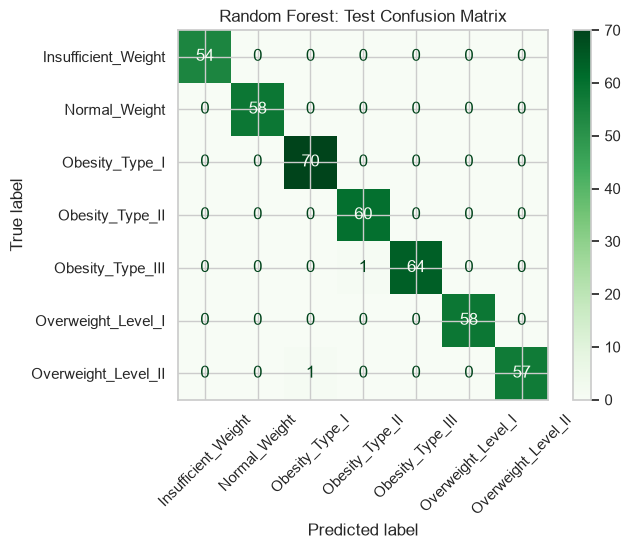

Random Forest classification report:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)
logistic_model.fit(X_ob_train_scaled, y_ob_train)

forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
forest_classifier.fit(X_ob_train_scaled, y_ob_train)


# TODO: Predict on train, validation, and test.
logistic_train_pred = logistic_model.predict(X_ob_train_scaled)
logistic_val_pred = logistic_model.predict(X_ob_val_scaled)
logistic_test_pred = logistic_model.predict(X_ob_test_scaled)

forest_train_pred = forest_classifier.predict(X_ob_train_scaled)
forest_val_pred = forest_classifier.predict(X_ob_val_scaled)
forest_test_pred = forest_classifier.predict(X_ob_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
def evaluate_classifier(y_true, y_pred, set_name):
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{set_name}: Accuracy = {accuracy:.3f}, Macro-F1 = {macro_f1:.3f}")

print("LOGISTIC REGRESSION")
evaluate_classifier(y_ob_train, logistic_train_pred, "Training")
evaluate_classifier(y_ob_val, logistic_val_pred, "Validation")
evaluate_classifier(y_ob_test, logistic_test_pred, "Test")

print("\nRANDOM FOREST")
evaluate_classifier(y_ob_train, forest_train_pred, "Training")
evaluate_classifier(y_ob_val, forest_val_pred, "Validation")
evaluate_classifier(y_ob_test, forest_test_pred, "Test")


# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?
ConfusionMatrixDisplay.from_predictions(
    y_ob_test,
    forest_test_pred,
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    cmap="Greens"
)

plt.title("Random Forest: Test Confusion Matrix")
plt.show()

print("Random Forest classification report:")
print(
    classification_report(
        y_ob_test,
        forest_test_pred,
        target_names=target_encoder.classes_
    )
)

Student Reasoning — Classification evaluation & overfitting 

1. I chose the Random Forest classifier because it performed better than Logistic Regression.

2. The Random Forest was well-fitted. Its training accuracy and Macro-F1 were both 1.000. Its validation accuracy and Macro-F1 were both 0.993, and its test accuracy and Macro-F1 were both 0.995. The scores are very close, so there is only a small sign of overfitting.

3. The confusion matrix shows that Obesity_Type_III was confused once with Obesity_Type_II. Also, Overweight_Level_II was confused once with Obesity_Type_I. These levels may be difficult to separate because people in nearby obesity categories can have similar height, weight, BMI, and lifestyle values.

# Section 3 — Unsupervised Learning: K-Means Clustering

Part 3.1 — Choose k, fit K-Means, and visualise


Clustering feature matrix shape: (2111, 20)


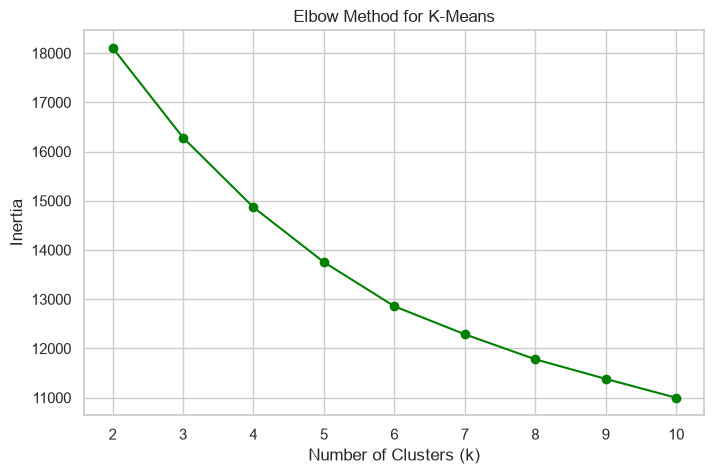

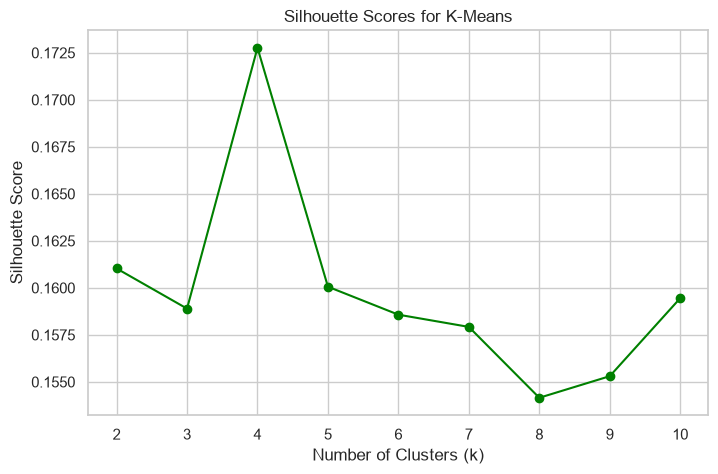

Silhouette scores:
k = 2: 0.161
k = 3: 0.159
k = 4: 0.173
k = 5: 0.160
k = 6: 0.159
k = 7: 0.158
k = 8: 0.154
k = 9: 0.155
k = 10: 0.159

K-Means completed with k = 4


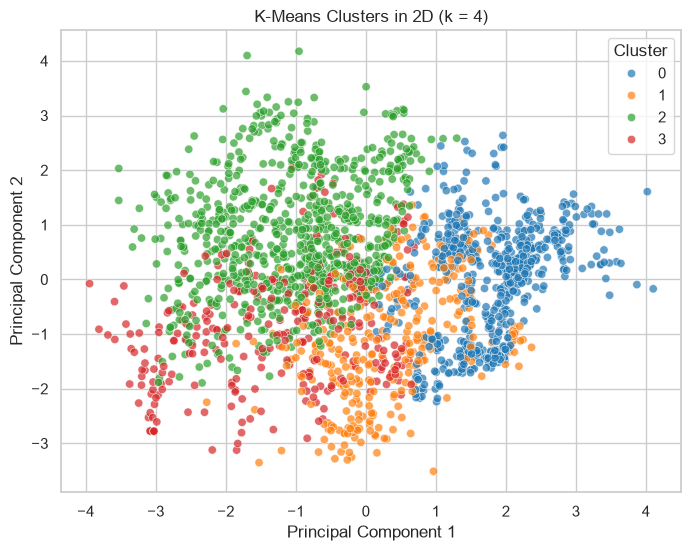

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = pd.concat([
    X_ob_train_scaled,
    X_ob_val_scaled,
    X_ob_test_scaled
], axis=0)

print("Clustering feature matrix shape:", X_cluster.shape)
# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, cluster_labels)
    )

# Elbow plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o", color="green")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Silhouette score plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o", color="green")
plt.title("Silhouette Scores for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

print("Silhouette scores:")
for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: {score:.3f}")


# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 4

kmeans_final = KMeans(
    n_clusters=chosen_k,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster)

print(f"\nK-Means completed with k = {chosen_k}")


# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_cluster_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_cluster_pca[:, 0],
    y=X_cluster_pca[:, 1],
    hue=cluster_labels,
    palette="tab10",
    alpha=0.7
)

plt.title(f"K-Means Clusters in 2D (k = {chosen_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [13]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
cluster_vs_obesity = pd.crosstab(
    cluster_labels,
    obesity["NObeyesdad"]
)

print("Clusters compared with true obesity levels:")
display(cluster_vs_obesity)

Clusters compared with true obesity levels:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,81,85,106,89,98,86,81
1,43,46,46,49,54,47,48
2,103,118,144,106,128,112,119
3,45,38,55,53,44,45,42



Student Reasoning — Clustering 
1. I chose k = 4 because it had the highest silhouette score, 0.173. The other scores were lower, for example 0.161 for k = 2 and 0.160 for k = 5. The elbow plot also started to become less steep around k = 4.

2. The clusters do not match the real obesity levels clearly. Each cluster contains people from all seven obesity categories. For example, Cluster 2 includes 103 Insufficient Weight, 118 Normal Weight, 144 Obesity Type I, and 128 Obesity Type III. This shows that the clusters find general profiles, but not the exact obesity categories.

3. In public health, these clusters could help group people with similar body and lifestyle characteristics when obesity labels are not available. Health workers could use the groups to plan general health education, screening, or prevention programs for similar people.

# Section 4 — Reflection

1. Supervised vs unsupervised: The classifier learned from the real obesity labels, so it could predict the correct obesity category very well. K-Means did not use the labels. It only grouped people with similar features, so its clusters did not match the obesity levels clearly.

2. Regression vs classification: In regression, I predicted a continuous value, tip_amount. I used RMSE and R² to check how close the predicted tips were to the real tips. In classification, I predicted obesity categories. I used accuracy, Macro-F1, and a confusion matrix to check correct and incorrect categories.

3. Overfitting: The biggest train-versus-test gap was in the Random Forest regression model. Its training RMSE was 2.841 and R² was 0.668, but its test RMSE was 5.624 and R² was -0.194. This shows overfitting. To reduce it, I would limit the depth of the trees using max_depth.